## Quick Overview
#### This dataset contains retail transaction records from an online shopping business. Each row represents a product purchased in a customer transaction. The dataset is useful for analyzing sales trends, customer purchasing behavior, product performance, and business operations.

### Dataset Information
#### Total Records: Approximately 1 million transactions
#### Total Features: 8 columns
#### Dataset Type: E-commerce / Retail Transaction **Dataset**

In [0]:
# Importing important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# globally setting
pd.options.display.float_format = '{:.2f}'.format
sns.set_theme(palette="flare")

In [0]:
# Loading the dataset
TABLE_NAME = "workspace.e_commerce.e_commerce_dataset"

print(f'{'=' * 10} Dataset is loading........')
df = spark.table(TABLE_NAME).toPandas()
print(f'{'=' * 10} Dataset is loaded successful')


========== Dataset is loading........
========== Dataset is loaded successful


In [0]:
# Shape of the dataset
print(f'Shape of the dataset: {df.shape}') #// (Rows, column)

Shape of the dataset: (1048575, 8)


### Basis check

In [0]:
# columns names in the dataset
column_names = df.columns.tolist()
print(f'Column Names: {column_names}')

# Find null or missing values in the dataset
missing_values = df.isnull().sum().sort_values(ascending = False)
print(f'\nTotal missing values in dataset:\n{missing_values}')

Column Names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Total missing values in dataset:
Customer ID    236682
Description      4372
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64


In [0]:
# Checking datatypes

check_datatype = pd.DataFrame(df.dtypes, columns=['Type'])

print(f"\nDatatypes Schema:") # Print your label first
print(check_datatype)      # Print the DataFrame on a new line


Datatypes Schema:
                Type
Invoice       object
StockCode     object
Description   object
Quantity       int64
InvoiceDate   object
Price        float64
Customer ID  float64
Country       object


In [0]:
# info 
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [0]:
# description

describe = df.describe()
print(describe)

        Quantity      Price  Customer ID
count 1048575.00 1048575.00    811893.00
mean        9.96       4.63     15324.71
std       133.52     122.80      1697.03
min    -74215.00  -53594.36     12346.00
25%         1.00       1.25     13971.00
50%         3.00       2.10     15260.00
75%        10.00       4.15     16795.00
max     74215.00   38970.00     18287.00


In [0]:
# Check negative & zero values in numeric columns

df_num_cols = df.select_dtypes(include = ['int64', 'float64'])

demo_num_summary = pd.DataFrame({
        'Negative count' : (df_num_cols < 0).sum(),
        'zero values': (df_num_cols == 0).sum(),
        'negative_%': (df_num_cols < 0).mean() * 100,
        'Zero_value_%' : (df_num_cols == 0).mean() *100
})
print(demo_num_summary)

             Negative count  zero values  negative_%  Zero_value_%
Quantity              22697            0        2.16          0.00
Price                     5         6166        0.00          0.59
Customer ID               0            0        0.00          0.00


In [0]:
# Identifying duplicate records
dupllicated_records = df.duplicated().sum() # detected duplicated records
print(f'Total Duplicated Records: {dupllicated_records}')

# Removing duplicated records
df = df.drop_duplicates()
print(f'Duplicated record removed!')
print(f'\nShape of dataset: {df.shape}')

Total Duplicated Records: 34150
Duplicated record removed!

Shape of dataset: (1014425, 8)


In [0]:
# safely renaming the column name
df_copy = df.copy()

# Define your mapping
mapping = {
    'StockCode': 'Stock_code',
    'InvoiceDate': 'Invoice_Date',
    'Customer ID': 'Customer_ID'
}
# Apply the rename
df_copy = df_copy.rename(columns=mapping) # Renaming columns
df_copy.columns = df_copy.columns.str.strip() # removes whitespace from the columns
column_name = df_copy.columns.tolist()
print(column_name)

['Invoice', 'Stock_code', 'Description', 'Quantity', 'Invoice_Date', 'Price', 'Customer_ID', 'Country']


In [0]:
df_copy = df_copy[(df_copy['Quantity'] > 0) & (df_copy['Price'] > 0)]

In [0]:
# Converting Invoice_Date to date and time
df_copy['Invoice_Date'] = pd.to_datetime(df_copy.Invoice_Date) # covnert to datetime

# Extract into separate columns
df_copy['year'] = df_copy['Invoice_Date'].dt.year 
df_copy['month'] = df_copy['Invoice_Date'].dt.month
df_copy['day'] = df_copy['Invoice_Date'].dt.day
df_copy['Hour'] = df_copy['Invoice_Date'].dt.hour

df_copy.dtypes

Invoice                 object
Stock_code              object
Description             object
Quantity                 int64
Invoice_Date    datetime64[ns]
Price                  float64
Customer_ID            float64
Country                 object
year                     int32
month                    int32
day                      int32
Hour                     int32
dtype: object

In [0]:
df_copy.head()

,Invoice,Stock_code,Description,Quantity,Invoice_Date,Price,Customer_ID,Country,year,month,day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,2009,12,1,7


In [0]:
# droping empty or missing values in the dataset
# Customer_ID
# Description

df_copy['Customer_ID'] = df_copy['Customer_ID'].fillna(0)
df_copy
df_copy['Description'] =df_copy['Description'].fillna('Unknown').astype('str')

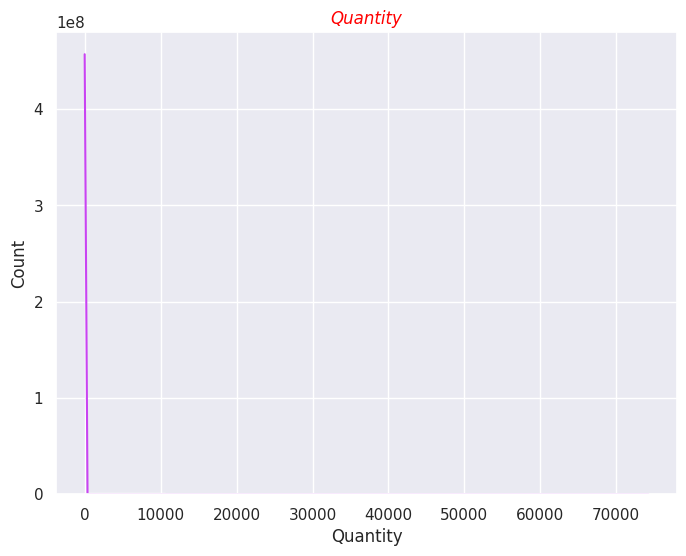

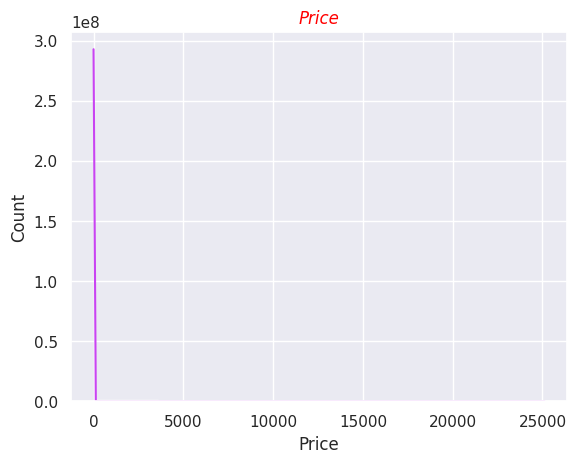

In [0]:
# specifying the figure size
plt.figure(figsize=(8, 6))

# columns to check outliers
columns = ['Quantity', 'Price']
color = '#C944F2'

for i in columns:
    sns.histplot(
        data = df_copy,
        x = df_copy[i],
        bins = 7,
        kde = True,
        color = color
    )

    plt.title(i, color = 'red', style = 'italic')
    plt.show()


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105066
WHITE HANGING HEART T-LIGHT HOLDER     94043
ASSORTED COLOUR BIRD ORNAMENT          79384
MEDIUM CERAMIC TOP STORAGE JAR         77856
JUMBO BAG RED RETROSPOT                77236
BROCADE RING PURSE                     70092
PACK OF 60 PINK PAISLEY CAKE CASES     55853
60 TEATIME FAIRY CAKE CASES            53934
SMALL POPCORN HOLDER                   48561
PACK OF 72 RETROSPOT CAKE CASES        47842
Name: Quantity, dtype: int64


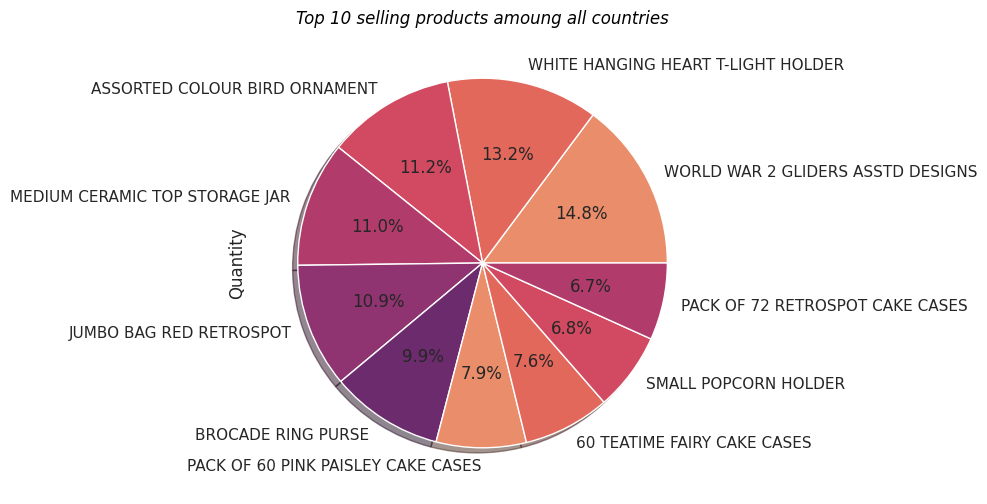

In [0]:
# Identification of top 10 selling products amoung all countries

top_selling_product = df_copy.groupby(['Description'])['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_selling_product)

# specifying the figure size
plt.figure(figsize = (8, 6))

# plotling
top_selling_product.plot(kind = 'pie',
                         autopct= '%1.1f%%',
                         shadow = True,)

plt.title('Top 10 selling products amoung all countries', color = 'black', style = 'italic')
plt.show()

   year  TotalSales
0  2009   822483.95
1  2010  9833473.98
2  2011  9302786.50


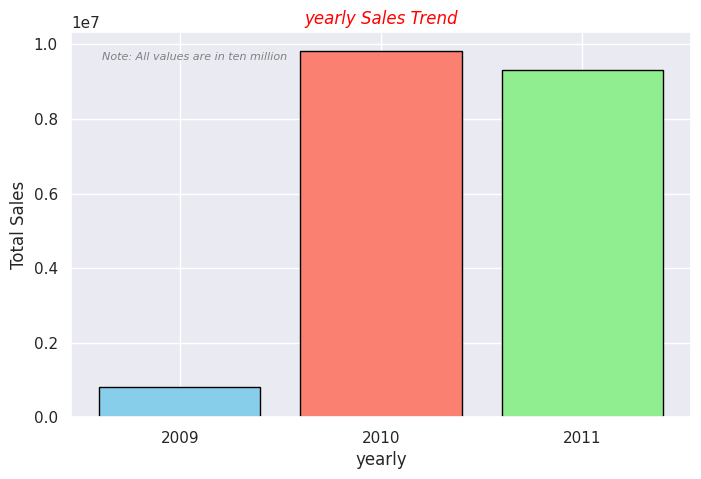

In [0]:
# Analyzing yearly sales trends


# Convert all negative quantities to positive
df_copy['Quantity'] = df_copy['Quantity'].abs()
df_copy['Total_price'] = round(df_copy['Quantity'] * df_copy['Price'],2) # Total 

#price customer paid for a product
yearly_sales = df_copy.groupby(['year'])['Total_price'].sum().reset_index()
yearly_sales.rename(columns={'Total_price': 'TotalSales'}, inplace=True)
print(yearly_sales)

# specifying the figure size
plt.figure(figsize=(8,5))

# creating list of colors for bar function
colors = ['skyblue', 'salmon', 'lightgreen']

# Bar plot to show yearly sales
plt.bar(yearly_sales['year'],
         yearly_sales['TotalSales'],
         color = colors, 
         edgecolor = 'black')  #edgecolor for better definition
plt.xticks(yearly_sales['year'])

ax = plt.gca()
plt.text(0.05, 0.95, 'Note: All values are in ten million',  
        verticalalignment='top',
        fontsize=8,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')
    
plt.title('yearly Sales Trend', color = 'red', style = 'italic')
plt.xlabel('yearly')
plt.ylabel('Total Sales')
plt.show()

year       2009       2010       2011
month                                
1           NaN  651155.11  689811.61
2           NaN  551878.29  522545.56
3           NaN  830915.26  716215.26
4           NaN  678875.25  536968.49
5           NaN  657705.50  769296.61
6           NaN  749537.31  760547.01
7           NaN  648810.27  718076.12
8           NaN  695251.91  757841.38
9           NaN  921696.99 1056435.19
10          NaN 1161902.22 1151263.73
11          NaN 1464293.14 1503866.78
12    822483.95  821452.73  119918.76


<Figure size 1200x600 with 0 Axes>

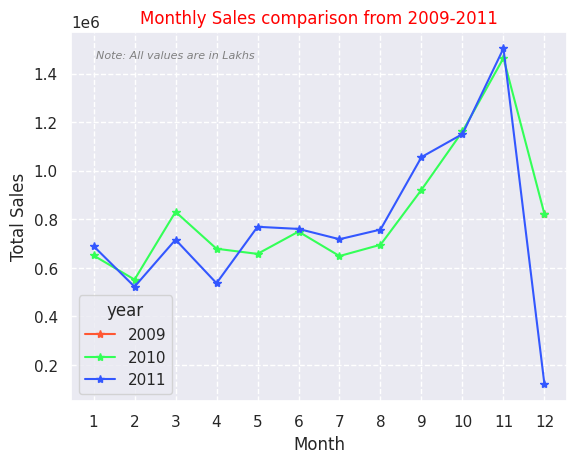

In [0]:
# Summarying sales by month and year
monthly_yearly_sales = df_copy.groupby(['year', 'month'])['Total_price'].sum().reset_index()

# Rename for clarity
monthly_yearly_sales.rename(columns={'Total_price': 'TotalSales'}, inplace=True)


pivot_sales = monthly_yearly_sales.pivot(
    index = 'month',
    columns = 'year',
    values = 'TotalSales'
)

print(pivot_sales)

# plotting
# specifying the figure size
plt.figure(figsize = (12, 6))

# custom color used
colors = ['#FF5733', '#33FF57', '#3357FF']

# creating line plot
pivot_sales.plot(kind ='line',
                marker = '*',
                color = colors,
                )
ax = plt.gca()
plt.text(0.05, 0.95, 'Note: All values are in Lakhs',  
        verticalalignment='top',
        fontsize=8,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')

# formatting on x-axis
plt.xticks(range(1, 13))
plt.title('Monthly Sales comparison from 2009-2011', color = 'red')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, linestyle = '--')
plt.legend(title = 'year', loc = 'lower left')
plt.show()

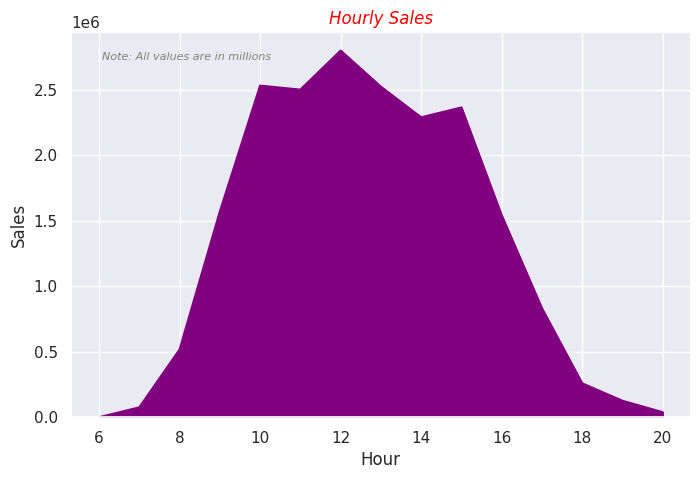

In [0]:
df_copy['Hour'] = df_copy['Invoice_Date'].dt.hour
hourly_sales = df_copy.groupby('Hour')['Total_price'].sum()

plt.figure(figsize=(8,5))

ax = plt.gca()
plt.text(0.05, 0.95, 'Note: All values are in millions',  
        verticalalignment='top',
        fontsize=8,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')

hourly_sales.plot(kind='area', color = 'purple')
plt.title("Hourly Sales", color = 'red', style = 'italic')
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Country
United Kingdom   16931306.29
EIRE               652465.34
Netherlands        542310.07
Germany            417798.41
France             345671.81
Australia          169283.46
Spain              108016.28
Switzerland        100685.59
Sweden              91631.82
Denmark             68411.79
Name: Total_price, dtype: float64


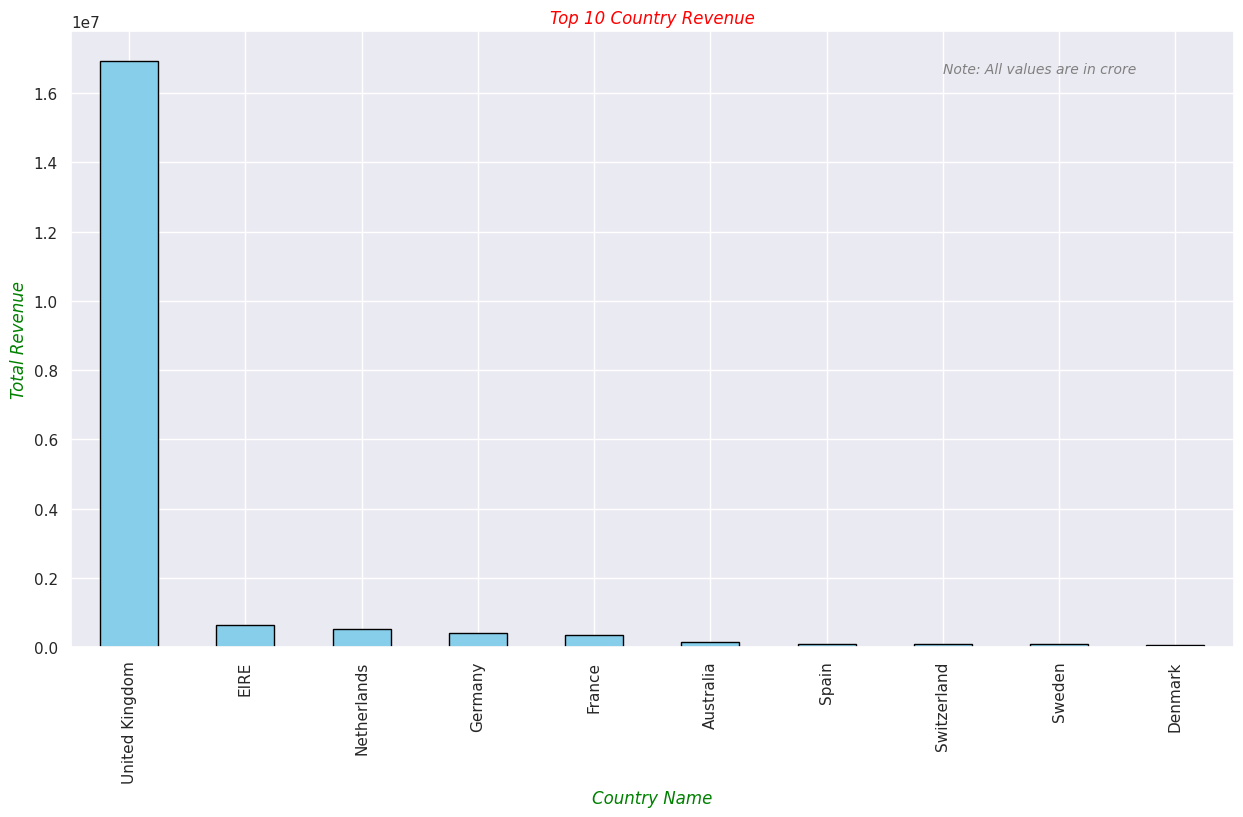

In [0]:
# Top 10 Country revenue generation

# top 10 countries
top_country_sales = df_copy.groupby(['Country'])['Total_price'].sum().sort_values(ascending = False).head(10)
print(top_country_sales)


# specifying the figure size
plt.figure(figsize = (15, 8))

# Plotting
top_country_sales.plot(kind = 'bar',
                   color = 'skyblue',
                   edgecolor = 'black')

# adding a note
ax = plt.gca()
plt.text(0.75, 0.95, 'Note: All values are in crore',  
        verticalalignment='top',
        fontsize=10,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')


# graph formatting
plt.title('Top 10 Country Revenue', color = 'red', style = 'italic')
plt.xlabel('Country Name', color='green', style = 'italic')
plt.ylabel('Total Revenue', color = 'green', style = 'italic')
plt.show()

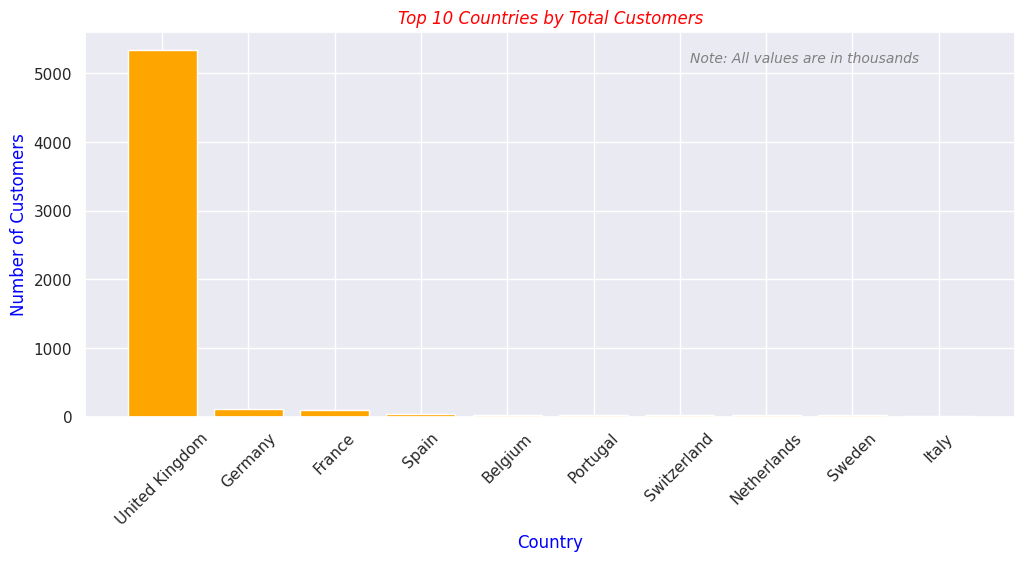

In [0]:
# Top 10 Countries by Total Customers

# calculate unique customer
country_customers = df_copy.groupby('Country')['Customer_ID'].nunique().reset_index()
country_customers.rename(columns={'Customer_ID': 'TotalCustomers'}, inplace=True)
# Top 10 customer
country_customers.sort_values(by='TotalCustomers', ascending=False).head(10)

top_countries = country_customers.sort_values(
    by='TotalCustomers',
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(top_countries['Country'],
        top_countries['TotalCustomers'],
        color = 'orange')


ax = plt.gca()
plt.text(0.65, 0.95, 'Note: All values are in thousands',  
        verticalalignment='top',
        fontsize=10,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')

plt.title('Top 10 Countries by Total Customers', color = 'red', style = 'italic')
plt.xlabel('Country', color = 'blue')
plt.ylabel('Number of Customers', color = 'blue')

plt.xticks(rotation=45)

plt.show()

In [0]:
# Dwonloading clean dataset
df_copy.to_csv('Clean_dataset.csv')